In [8]:
import os

from gnssrefl.utils import check_environment, set_environment, get_sys
from pathlib import Path
from gnssrefl.quickLook_cl import quicklook

# Making sure environment variables are set - this is required to run the gnssrefl code
notebook_dir = Path.cwd().parents[0]

exists = check_environment()
if exists == False:
    #If you are running this locally - make sure the items in the exe folder have execution permissions
    set_environment(refl_code=str(notebook_dir),
                    orbits=str(notebook_dir / "orbits"),
                    exe=str(notebook_dir / "exe"))

# Set local variable of refl_code location
refl_code_loc = os.environ['REFL_CODE']
print("refl_code location:", refl_code_loc)

refl_code location: /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks


In [4]:
print('files in exe folder:', os.listdir(os.environ['EXE']))

#import gnssrefl rinex2snr function (environment variables must be set first)
from gnssrefl.rinex2snr_cl import rinex2snr
from gnssrefl.installexe_cl import installexe

# Download the executables
try:
    os.environ['DOCKER']
except KeyError:
    sys = get_sys()
    installexe(sys)

files in exe folder: ['CRX2RNX', '.gitkeep', 'gfzrnx']
Your executable environment area:  /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/exe
There is no teqc executable for this architecture, so none will be installed.
This Hatanaka executable already exists
The gfzrnx executable already exists


In [7]:
import shutil, os
src = '/Users/brmills/Documents/SSiSLS/GNSSIR_project/umnq-2026001-2026031/umnq0010.26d.Z'
shutil.copy(src, os.getcwd())   # or os.symlink(src, ...)

station = 'umnq'
year = 2026
doy = 1

rinex2snr(station=station, year=year, doy=doy, nolook=True, orb='gnss3', overwrite=True)


No json file found - but you have requested the code not exit
Using snr value of  66
Using command line orbit selection of  gnss3
Using archive value of  all
Station  umnq  has four characters, assume RINEX 2.11 format
Debug mode or only analyzing one day of data. 
SNR file exists/you requested overwriting, existing file will be deleted
umnq 2026 1
General log:  /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/logs/umnq/2026/001_translation.txt.gen
Will first assume station  umnq  year: 2026  doy: 1 is located here : /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/learn-the-code
Looked for  /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/learn-the-code/umnq0010.26o
Failed, will search other names/directories
Looking for file:  /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/learn-the-code/umnq0010.26o.gz
Looking for file:  /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/learn-the-code/umnq0010.26o.Z
Looking for file:  /Users/brmills/Documents

/Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/Files/umnq  has been created.
Did not find station coordinates : umnq
Although no station coordinates were found, this is ok for quickLook.
minimum elevation angle (degrees) for this dataset:  0.0002
Plot saved to  /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/Files/umnq/quickLook_lsp.png
Plot saved to  /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/Files/umnq/quickLook_summary.png


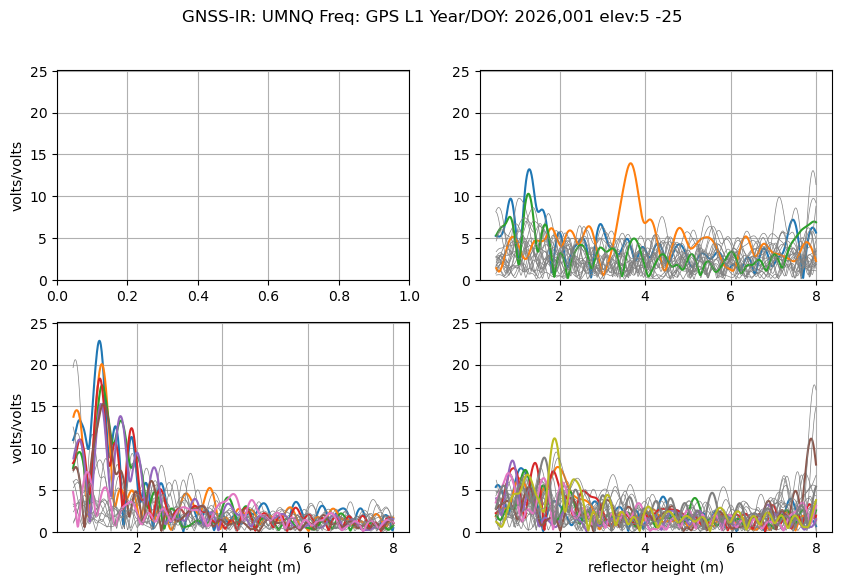

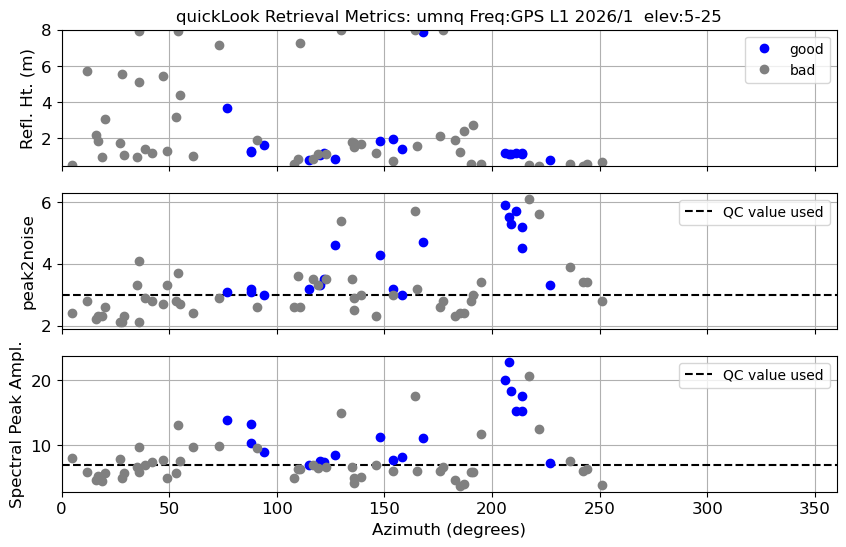

In [9]:
values, metrics = quicklook(station, year, doy=doy, plt=True)

In [10]:
import os, math, shutil, subprocess, tempfile
from pathlib import Path

def station_coords_from_rinex(rinex_path):
    """Extract approximate lat/lon/height from a RINEX 2.x obs file header."""
    src = Path(rinex_path)
    crx2rnx = Path(os.environ['EXE']) / 'CRX2RNX'

    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        local = tmp / src.name
        shutil.copy(src, local)

        # decompress .Z or .gz
        if local.suffix == '.Z':
            subprocess.run(['uncompress', '-f', str(local)], check=True)
            local = local.with_suffix('')
        elif local.suffix == '.gz':
            subprocess.run(['gunzip', '-f', str(local)], check=True)
            local = local.with_suffix('')

        # Hatanaka expand (.d -> .o) if needed
        if local.suffix.endswith('d'):
            subprocess.run([str(crx2rnx), str(local)], check=True)
            local = local.with_suffix(local.suffix[:-1] + 'o')

        # parse APPROX POSITION XYZ from header
        with open(local) as f:
            for line in f:
                if 'APPROX POSITION XYZ' in line:
                    X, Y, Z = (float(v) for v in line.split()[:3])
                    break
                if 'END OF HEADER' in line:
                    raise ValueError('APPROX POSITION XYZ not found in header')

    # WGS-84 ECEF -> geodetic (Bowring's method)
    a, f_ = 6378137.0, 1/298.257223563
    e2 = f_*(2 - f_); b = a*(1 - f_); ep2 = (a*a - b*b)/(b*b)
    p = math.hypot(X, Y)
    th = math.atan2(Z*a, p*b)
    lon = math.atan2(Y, X)
    lat = math.atan2(Z + ep2*b*math.sin(th)**3, p - e2*a*math.cos(th)**3)
    N = a / math.sqrt(1 - e2*math.sin(lat)**2)
    h = p/math.cos(lat) - N

    return math.degrees(lat), math.degrees(lon), h, (X, Y, Z)


rinex_file = '/Users/brmills/Documents/SSiSLS/GNSSIR_project/umnq-2026001-2026031/umnq0010.26d.Z'
lat, lon, height, (X, Y, Z) = station_coords_from_rinex(rinex_file)

print(f'File      : {Path(rinex_file).name}')
print(f'ECEF (m)  : X={X:.4f}  Y={Y:.4f}  Z={Z:.4f}')
print(f'Latitude  : {lat:.6f}  deg N')
print(f'Longitude : {lon:.6f}  deg E')
print(f'Height    : {height:.2f}  m (WGS-84 ellipsoid)')


File      : umnq0010.26d.Z
ECEF (m)  : X=1299844.0217  Y=-1670650.2585  Z=5996508.2707
Latitude  : 70.677526  deg N
Longitude : -52.115415  deg E
Height    : 38.00  m (WGS-84 ellipsoid)


In [18]:
from IPython.display import IFrame
from urllib.parse import urlencode

params = {
    'station': '',                  # must be present (even empty) or the server errors
    'lat':    f'{lat:.6f}',
    'lon':    f'{lon:.6f}',
    'height': f'{height:.2f}',
}
url = f'https://gnss-reflections.org/geoid?{urlencode(params)}'
print(url)
IFrame(url, width=1000, height=600)



https://gnss-reflections.org/geoid?station=&lat=70.677526&lon=-52.115415&height=38.00


nominal MSL height 10.88

In [21]:
from IPython.display import IFrame
from urllib.parse import urlencode

params = {
    'station': 'umnq',
    'lat':    f'{lat:.6f}',
    'lon':    f'{lon:.6f}',
    'height': f'{height:.2f}',
    'msl':    'msl',          # subtract geoid -> RH measured from MSL
    'RH':     '10.88',         # nominal reflector height (m) from your note
    'freq':   '1',             # L1
    'nyquist':'0',
    'srate':  '15',            # matches RINEX INTERVAL
    'eang':   '1',             # 5,10,15 deg preset
    'azim1':  '30',
    'azim2':  '180',
    'system': 'gps',
}
url = f'https://gnss-reflections.org/rzones?{urlencode(params)}'
print(url)
IFrame(url, width=900, height=600)


https://gnss-reflections.org/rzones?station=umnq&lat=70.677526&lon=-52.115415&height=38.00&msl=msl&RH=10.88&freq=1&nyquist=0&srate=15&eang=1&azim1=30&azim2=180&system=gps


Did not find station coordinates : umnq
Although no station coordinates were found, this is ok for quickLook.
minimum elevation angle (degrees) for this dataset:  0.0002
Plot saved to  /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/Files/umnq/quickLook_lsp.png
Plot saved to  /Users/brmills/Documents/SSiSLS/GNSSIR_project/notebooks/Files/umnq/quickLook_summary.png


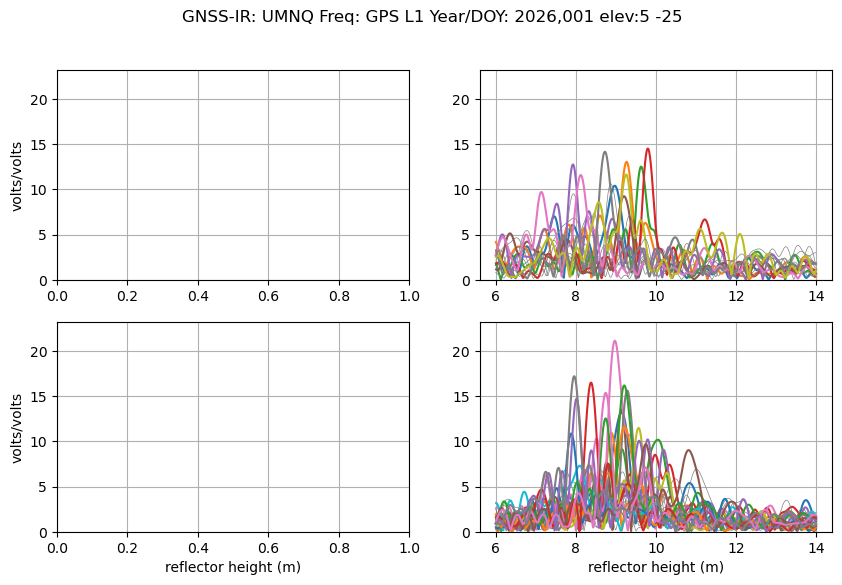

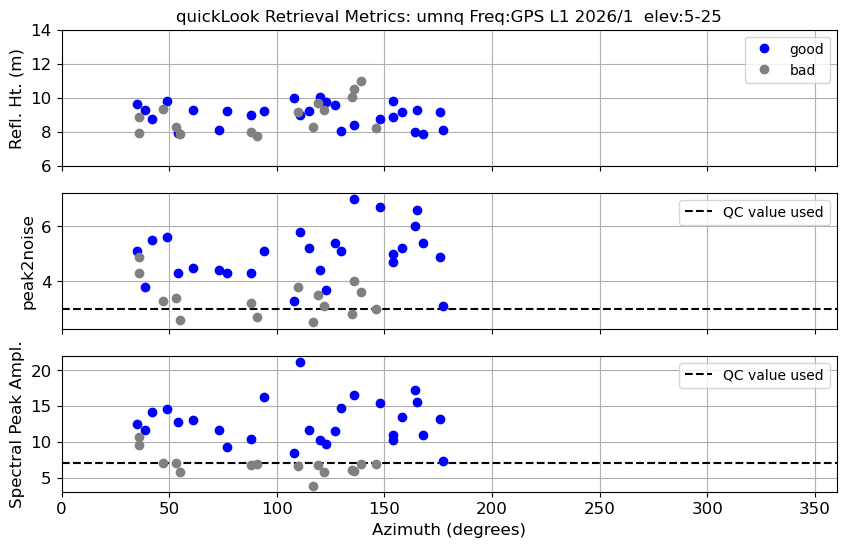

In [26]:
values, metrics = quicklook(
    station, year, doy=doy,
    fr=1,           # 1=L1, 2=L2, 5=L5, 20=L2C, 101/102=Glonass L1/L2
    azim1=30,
    azim2=180,
    h1=6,            # lower RH limit (m) - below expected
    h2=14,           # upper RH limit (m) - above expected, leaves room for low tide
    plt=True,
)



In [33]:
import gzip, os
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import lombscargle

# --- locate SNR file (snr66 = elev mask 5–30 deg by default)
yy = str(year)[-2:]
snr_dir = Path(os.environ['REFL_CODE']) / f'{year}' / 'snr' / station
snr_path = snr_dir / f'{station}{doy:03d}0.{yy}.snr66'
if not snr_path.exists():
    snr_path = snr_path.with_suffix('.snr66.gz')
opener = gzip.open if snr_path.suffix == '.gz' else open

cols = ['sat','elev','azim','sec','edot','S6','S1','S2','S5']
with opener(snr_path, 'rt') as f:
    df = pd.read_csv(f, sep=r'\s+', header=None, names=cols, usecols=range(9))

# --- GPS L1/L2/L5 wavelengths (m)
c = 299_792_458.0
WL  = {'L1': c/1575.42e6, 'L2': c/1227.60e6, 'L5': c/1176.45e6}
COL = {'L1':'S1', 'L2':'S2', 'L5':'S5'}

# --- analysis windows (match what you used in quickLook)
AZ_MIN, AZ_MAX = 30, 180
E_MIN,  E_MAX  = 5, 25
H_MIN,  H_MAX  = 5, 14
PEAK2NOISE_MIN = 3.0     # quality flag: peak / median(periodogram)

def estimate_rh(elev_deg, snr_db, wavelength):
    """Lomb-Scargle peak -> reflector height (m). Returns (RH, amplitude, p2n)."""
    mask = snr_db > 0
    if mask.sum() < 20:
        return np.nan, np.nan, np.nan
    e = elev_deg[mask]
    snr_lin = 10 ** (snr_db[mask] / 20.0)           # dB-Hz -> volts
    se = np.sin(np.radians(e))
    # detrend SNR with quadratic in sin(elev) to remove direct signal
    dsnr = snr_lin - np.polyval(np.polyfit(se, snr_lin, 2), se)
    # evaluate periodogram on a grid of candidate heights
    heights = np.linspace(H_MIN, H_MAX, 2000)
    omegas  = 4 * np.pi * heights / wavelength      # rad per unit sin(elev)
    pgram   = lombscargle(se, dsnr, omegas, normalize=True)
    i = int(np.argmax(pgram))
    return heights[i], float(pgram[i]), float(pgram[i] / np.median(pgram))

# --- select GPS arcs within window, split into rising/setting + time-gap passes
gps = df[(df.sat.between(1, 32)) &
         (df.azim.between(AZ_MIN, AZ_MAX)) &
         (df.elev.between(E_MIN, E_MAX))].copy()
gps['dir'] = np.where(gps.edot > 0, 'rise', 'set')

rows = []
debug = []
for (sat, direction), g in gps.groupby(['sat', 'dir']):
    g = g.sort_values('sec').reset_index(drop=True)
    splits = np.where(np.diff(g.sec.values) > 1800)[0] + 1
    bounds = [0, *splits, len(g)]
    for pass_idx in range(len(bounds) - 1):
        sub = g.iloc[bounds[pass_idx]:bounds[pass_idx + 1]]
        debug.append((int(sat), direction, pass_idx, len(sub)))
        if len(sub) < 20:
            continue
        row = {
            'sat':     int(sat),
            'dir':     direction,
            'pass':    pass_idx,
            'az_mean': round(sub.azim.mean(), 1),
            't0_hr':   round(sub.sec.min() / 3600, 2),
            'n_pts':   len(sub),
        }
        for band in ('L1', 'L2', 'L5'):
            rh, amp, p2n = estimate_rh(sub.elev.values, sub[COL[band]].values, WL[band])
            row[f'RH_{band}']  = round(rh, 3)  if np.isfinite(rh)  else np.nan
            row[f'p2n_{band}'] = round(p2n, 1) if np.isfinite(p2n) else np.nan
        rows.append(row)

print(f'sub-passes generated : {len(debug)}')
print(f'sub-passes >= 20 pts : {sum(1 for _,_,_,n in debug if n >= 20)}')
print(f'rows appended        : {len(rows)}')
print()
print('First 20 sub-pass sizes:')
for d in debug[:20]:
    print(d)

import pandas as pd
results = pd.DataFrame(rows).sort_values(['t0_hr','sat']).reset_index(drop=True)
for band in ('L1', 'L2', 'L5'):
    bad = results[f'p2n_{band}'] < PEAK2NOISE_MIN
    results.loc[bad, f'RH_{band}'] = pd.NA

print(f'Arcs: {len(results)}')
for band in ('L1', 'L2', 'L5'):
    vals = results[f'RH_{band}'].dropna()
    if len(vals):
        print(f'  {band}: median={vals.median():.3f} m  n={len(vals)}  std={vals.std():.3f} m')

from IPython.display import display
display(results)


sub-passes generated : 55
sub-passes >= 20 pts : 54
rows appended        : 54

First 20 sub-pass sizes:
(1, 'set', 0, 180)
(2, 'rise', 0, 181)
(2, 'set', 0, 177)
(3, 'rise', 0, 184)
(3, 'set', 0, 176)
(4, 'rise', 0, 210)
(4, 'rise', 1, 11)
(4, 'set', 0, 208)
(5, 'rise', 0, 101)
(5, 'set', 0, 183)
(6, 'rise', 0, 107)
(6, 'set', 0, 185)
(7, 'rise', 0, 231)
(7, 'set', 0, 191)
(8, 'set', 0, 194)
(9, 'rise', 0, 197)
(9, 'set', 0, 198)
(10, 'rise', 0, 208)
(11, 'rise', 0, 291)
(11, 'set', 0, 182)
Arcs: 54
  L1: median=8.975 m  n=53  std=1.020 m
  L2: median=8.948 m  n=53  std=1.128 m
  L5: median=8.898 m  n=30  std=0.601 m


,sat,dir,pass,az_mean,t0_hr,n_pts,RH_L1,p2n_L1,RH_L2,p2n_L2,RH_L5,p2n_L5
0,28,rise,0,31.4,0.00,40,5.752,3.2,5.896,3.6,NaN,1.8
1,4,rise,0,115.1,0.02,210,10.034,44.6,9.034,30.8,9.156,54.7
2,1,set,0,87.6,0.21,180,8.989,23.8,8.876,60.0,8.845,118.6
3,31,rise,0,39.5,0.64,218,9.282,18.7,9.183,33.4,NaN,NaN
4,9,rise,0,135.9,0.76,197,11.020,28.3,8.948,10.6,8.957,22.7
5,17,set,0,158.4,1.28,186,9.133,58.7,9.102,41.2,NaN,NaN
6,3,set,0,60.8,1.75,176,9.273,27.4,9.115,59.6,9.111,13.6
7,19,set,0,166.1,1.94,179,9.286,96.8,9.205,59.9,NaN,NaN
8,7,rise,0,102.3,3.33,231,9.979,17.7,9.651,10.5,NaN,NaN
9,4,set,0,37.9,3.39,208,9.628,47.9,9.615,52.9,9.642,50.9


In [34]:
print(f'SNR rows total           : {len(df):,}')
print(f'After sat 1-32 filter    : {len(df[df.sat.between(1,32)]):,}')
print(f'After +az  {AZ_MIN}-{AZ_MAX}        : {len(df[(df.sat.between(1,32)) & (df.azim.between(AZ_MIN,AZ_MAX))]):,}')
print(f'After +elev {E_MIN}-{E_MAX}        : {len(gps):,}')
print(f'Unique GPS sats          : {sorted(gps.sat.unique())}')
print()
print('Largest (sat, dir) groups:')
print(gps.groupby(['sat','dir']).size().sort_values(ascending=False).head(10))
print()
print('Smallest (sat, dir) groups:')
print(gps.groupby(['sat','dir']).size().sort_values().head(10))


SNR rows total           : 72,465
After sat 1-32 filter    : 33,994
After +az  30-180        : 14,322
After +elev 5-25        : 10,100
Unique GPS sats          : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32)]

Largest (sat, dir) groups:
sat  dir 
17   rise    308
19   rise    296
11   rise    291
32   rise    289
23   rise    239
14   rise    235
7    rise    231
4    rise    221
22   rise    219
18   rise    219
dtype: int64

Smallest (sat, dir) groups:
sat  dir 
14   set      20
22   set      21
5    rise    101
6    rise    107
28   rise    108
18   set     163
13   set     173
3    set     176
2 

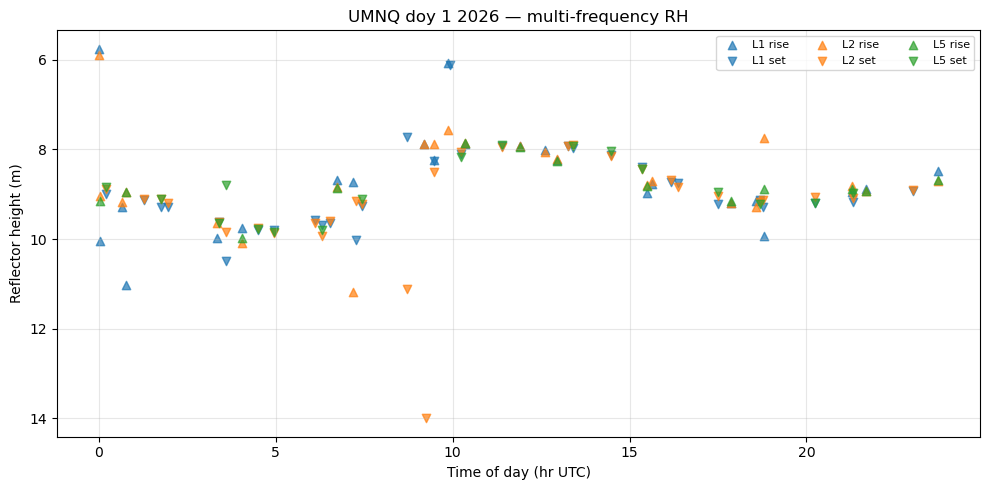

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for band, color in [('L1','C0'), ('L2','C1'), ('L5','C2')]:
    for direction, marker in [('rise','^'), ('set','v')]:
        sub = results[results.dir == direction]
        ax.scatter(sub.t0_hr, sub[f'RH_{band}'],
                   c=color, marker=marker, alpha=0.7,
                   label=f'{band} {direction}')
ax.set_xlabel('Time of day (hr UTC)')
ax.set_ylabel('Reflector height (m)')
ax.set_title(f'{station.upper()} doy {doy} {year} — multi-frequency RH')
ax.invert_yaxis()                          # so rising water = up on plot
ax.legend(ncol=3, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
